<a href="https://colab.research.google.com/github/Darshan5564/Darshan/blob/main/ANN_vs_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# importing the necessary lib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# keras package
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.utils import to_categorical

# import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [49]:
# importing the data
(x_train, y_train), (x_test,y_test) = keras.datasets.mnist.load_data()

# data dimensions
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [50]:
# check the target class
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [51]:
# min and max pixels
print('The minimum pixel value is:', x_train.min())
print('The max pixel value is:', x_train.max())

The minimum pixel value is: 0
The max pixel value is: 255


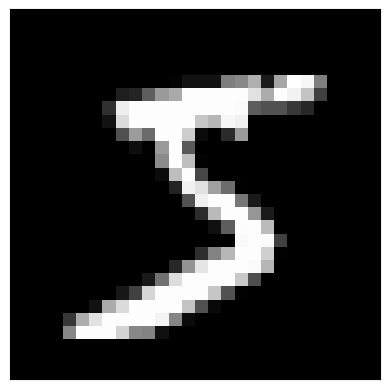


 the displayed image label is: 5


In [52]:
# print the fisrt image and its label
plt.imshow(x_train[0], cmap='grey')
plt.xticks([])
plt.yticks([])
plt.show()
print('\n the displayed image label is:', y_train[0])

In [53]:
# normalize the data
x_train = x_train/255
x_test = x_test/255

In [54]:
# y_train sample data before encoding
print('1st train sample before encoding:', y_train[0])

# converting the taget to one hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# y_train sample data after encoding
print('1st train sample after encoding:', y_train[0])

1st train sample before encoding: 5
1st train sample after encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [55]:
# building ANN

ann_model= Sequential([Flatten(),
                       Dense(128, activation='relu'),
                       Dropout(0.2),
                       Dense(64, activation='relu'),
                       Dropout(0.2),
                       Dense(10, activation='softmax')])

# compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [56]:
import time

# training the architecture
start_time = time.time()
ann_model.fit(x_train, y_train, epochs=10, validation_split=0.2)
end_time = time.time()

# calculate the time for computaion
ann_training_time = end_time - start_time
print('\n Time taken for training model:', round(ann_training_time,2),'seconds')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8871 - loss: 0.3680 - val_accuracy: 0.9549 - val_loss: 0.1507
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9478 - loss: 0.1758 - val_accuracy: 0.9668 - val_loss: 0.1074
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9593 - loss: 0.1350 - val_accuracy: 0.9642 - val_loss: 0.1132
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9649 - loss: 0.1148 - val_accuracy: 0.9727 - val_loss: 0.0928
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9711 - loss: 0.0967 - val_accuracy: 0.9734 - val_loss: 0.0875
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9729 - loss: 0.0868 - val_accuracy: 0.9759 - val_loss: 0.0887
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9748 - loss: 0.0803 - val_accuracy: 0.9755 - val_loss: 0.0849
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9764 - loss: 0.0719

In [57]:
# model predicton
y_pred_ann = ann_model.predict(x_test)
y_pred_ann = np.argmax(y_pred_ann, axis=1)

# convert the y test to interger format
y_test_flat = np.argmax(y_test, axis=1)

# printing the first values from prediction
print('\n The predicted value is:', y_pred_ann[0])
print('\n The actual value is:', y_test_flat[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 The predicted value is: 7

 The actual value is: 7



classification report:

               precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



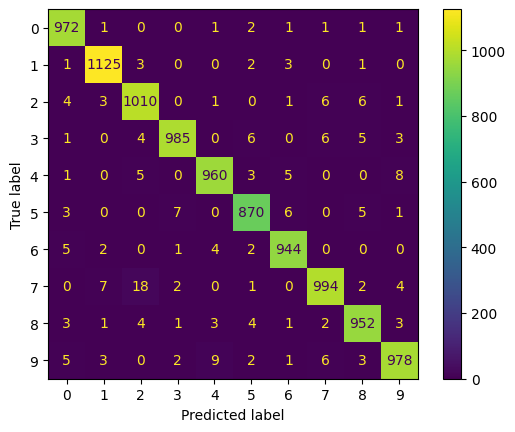

In [58]:
# metrics validation
cm_ann = ConfusionMatrixDisplay.from_predictions(y_test_flat, y_pred_ann)
print('\nclassification report:\n\n', classification_report(y_test_flat,y_pred_ann))

**Building the CNN**

In [59]:
# reloading the data
(x_train,y_train), (x_test,y_test) = keras.datasets.mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [60]:
# reshape the data into 4 dim so we can pass into the CNN
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype(np.float32)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype(np.float32)

# normalize the data
x_train /=255.0
x_test /=255.0

# convert the target to one hot encoading
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [61]:
# building a CNN

cnn_model = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
                        MaxPooling2D((2,2)),
                        Dropout(0.2),

                        Conv2D(64, (5,5), activation='relu'),
                        MaxPooling2D((2,2)),
                        Dropout(0.25),

                        Flatten(),

                        Dense(128, activation='relu'),
                        Dropout(0.3),
                        Dense(10, activation='softmax')])

# model compile
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
# training the architecture
start_time = time.time()
cnn_model.fit(x_train,y_train, epochs=5, validation_split=0.2)
end_time= time.time()

# calculating the time
cnn_time = end_time - start_time
print('\ncnn_training_time:', round(cnn_time,2),'seconds')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.9332 - loss: 0.2136 - val_accuracy: 0.9830 - val_loss: 0.0585
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 101s 67ms/step - accuracy: 0.9778 - loss: 0.0729 - val_accuracy: 0.9886 - val_loss: 0.0390
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 94s 63ms/step - accuracy: 0.9839 - loss: 0.0528 - val_accuracy: 0.9863 - val_loss: 0.0441
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.9855 - loss: 0.0455 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9883 - loss: 0.0371 - val_accuracy: 0.9908 - val_loss: 0.0311

cnn_training_time: 419.73 seconds


In [63]:
# model prediction
y_pred_cnn = cnn_model.predict(x_test)
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)

#convert the y_train back to interger form
y_test_flat = np.argmax(y_test, axis=1)

# printing the first value from prediction and actual value
print('The predicted vale:', y_pred_cnn[0])
print('The actual value:', y_test_flat[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
The predicted vale: 7
The actual value: 7



Classification report:

               precision    recall  f1-score   support

           0       0.99      1.00      1.00       979
           1       1.00      0.99      1.00      1137
           2       0.99      1.00      0.99      1030
           3       1.00      0.99      0.99      1012
           4       0.99      1.00      0.99       977
           5       0.99      0.99      0.99       895
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1034
           8       0.99      1.00      0.99       966
           9       0.99      0.99      0.99      1012

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



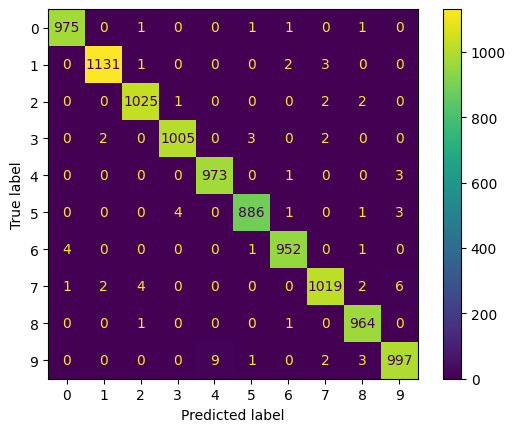

In [64]:
# metrics validation
cm = ConfusionMatrixDisplay.from_predictions(y_pred_cnn, y_test_flat)
print('\nClassification report:\n\n', classification_report(y_pred_cnn, y_test_flat))